In [19]:
#!pip install ucimlrepo
#!pip install optuna

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report
from ucimlrepo import fetch_ucirepo
import matplotlib.pyplot as plt
import xgboost as xgb
import pandas as pd
import numpy as np
import optuna
import shap

In [20]:
# =====================================================================
# PASO 1: PREPROCESAMIENTO
# =====================================================================
print("1. Cargando y limpiando datos...")
# fetch dataset
bank_marketing = fetch_ucirepo(id=222)

# data (as pandas dataframes)
df = bank_marketing.data.original

# Eliminar 'duration' para evitar fuga de datos
if 'duration' in df.columns:
    df = df.drop(columns=['duration'])

# Formatear la variable objetivo 'y'
if df['y'].dtype == 'object':
    df['y'] = df['y'].map({'no': 0, 'yes': 1})

# Separar características (X) y objetivo (y)
X = df.drop(columns=['y'])
y = df['y']

# Convertir variables categóricas a numéricas
X = pd.get_dummies(X, drop_first=True)

# Calcular el ratio de desbalance para XGBoost
ratio_desbalance = (y == 0).sum() / (y == 1).sum()

1. Cargando y limpiando datos...


In [21]:
print("Tamaño original del dataset:", df.shape)

Tamaño original del dataset: (45211, 16)


In [22]:
# =====================================================================
# PASO 2: SELECCIÓN DE LAS VARIABLES PRINCIPALES
# =====================================================================
print("2. Seleccionando el Top 10 de variables más importantes...")
# Entrenamos un modelo inicial rápido
modelo_borrador = xgb.XGBClassifier(
    scale_pos_weight=ratio_desbalance,
    random_state=42,
    n_jobs=-1
)
modelo_borrador.fit(X, y)

# Extraer la importancia de cada variable (Gain)
importancias = modelo_borrador.feature_importances_
nombres_variables = X.columns

# Crear una tabla temporal para ordenarlas
tabla_importancias = pd.DataFrame({'Variable': nombres_variables, 'Importancia': importancias})
tabla_importancias = tabla_importancias.sort_values(by='Importancia', ascending=False)

# Quedarnos solo con las 10 mejores
top_10_variables = tabla_importancias['Variable'].head(10).tolist()
X_filtrado = X[top_10_variables]

print(f"Variables seleccionadas: {top_10_variables}")

2. Seleccionando el Top 10 de variables más importantes...
Variables seleccionadas: ['poutcome_success', 'month_mar', 'month_oct', 'housing_yes', 'month_dec', 'month_may', 'month_sep', 'month_feb', 'month_nov', 'month_jan']


In [23]:
# =====================================================================
# PASO 3: VALIDACIÓN CRUZADA (Con los datos filtrados)
# =====================================================================
print("\n3. Ejecutando Validación Cruzada Estratificada (5 pliegues)...")
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

modelo_final = xgb.XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    scale_pos_weight=ratio_desbalance,
    random_state=42,
    n_jobs=-1
)

# Evaluamos usando F1-Score (ideal para clases desbalanceadas)
resultados_cv = cross_val_score(modelo_final, X_filtrado, y, cv=skf, scoring='f1', n_jobs=-1)

print(f"F1-Score promedio en validación: {resultados_cv.mean():.4f} (+/- {resultados_cv.std():.4f})")


3. Ejecutando Validación Cruzada Estratificada (5 pliegues)...
F1-Score promedio en validación: 0.3827 (+/- 0.0113)


In [24]:
# =====================================================================
# PASO 4: ENTRENAMIENTO FINAL Y EVALUACIÓN
# =====================================================================
print("\n4. Entrenando el modelo definitivo...")
# Dividimos los datos filtrados en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X_filtrado, y, test_size=0.2, random_state=42, stratify=y
)

# Entrenamos el modelo final
modelo_final.fit(X_train, y_train)

# Evaluamos en el conjunto de prueba
y_pred = modelo_final.predict(X_test)

print("\n--- Reporte de Clasificación Final ---")
print(classification_report(y_test, y_pred))


4. Entrenando el modelo definitivo...

--- Reporte de Clasificación Final ---
              precision    recall  f1-score   support

           0       0.92      0.93      0.92      7985
           1       0.41      0.36      0.39      1058

    accuracy                           0.86      9043
   macro avg       0.66      0.65      0.66      9043
weighted avg       0.86      0.86      0.86      9043




5. Generando visualización de interpretación (SHAP)...


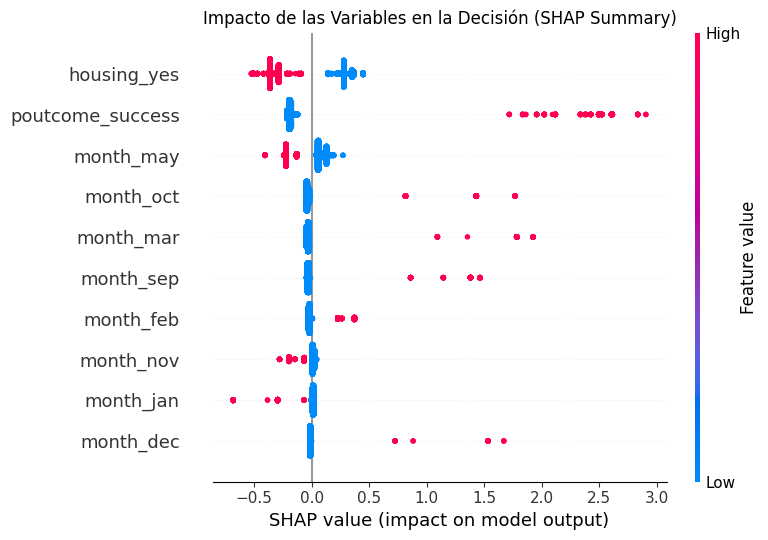

In [25]:
# =====================================================================
# PASO 5: INTERPRETACIÓN CON SHAP
# =====================================================================
print("\n5. Generando visualización de interpretación (SHAP)...")
# Configuramos el "explicador" matemático de SHAP
explainer = shap.TreeExplainer(modelo_final)

# Calculamos los valores SHAP para el conjunto de prueba
# (Usamos test para ver cómo toma decisiones en datos que no ha visto)
shap_values = explainer.shap_values(X_test)

# Mostramos el gráfico resumen
plt.title("Impacto de las Variables en la Decisión (SHAP Summary)")
shap.summary_plot(shap_values, X_test)

In [26]:
print("Iniciando Optimización Bayesiana con Optuna...")

# 1. Definir la función "Objetivo"
# Esta función es la que Optuna intentará maximizar (o minimizar).
def objective(trial):
    # Definimos el "menú" de parámetros que Optuna puede explorar.
    # trial.suggest_int o float le da los límites matemáticos para buscar.
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'max_depth': trial.suggest_int('max_depth', 3, 9),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),

        # Parámetros fijos que ya conocemos
        'scale_pos_weight': ratio_desbalance, # Vital para nuestro dataset desbalanceado
        'random_state': 42,
        'n_jobs': -1
    }

    # Instanciamos el modelo con los parámetros sugeridos en esta ronda
    modelo_xgb = xgb.XGBClassifier(**param)

    # Evaluamos el modelo usando Validación Cruzada Estratificada (5 pliegues)
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    score = cross_val_score(modelo_xgb, X_train, y_train, cv=skf, scoring='f1', n_jobs=-1)

    # Optuna necesita un solo número como calificación (el promedio de los 5 pliegues)
    return score.mean()

Iniciando Optimización Bayesiana con Optuna...


In [27]:
# 2. Crear el "Estudio" y ejecutar la optimización
# Le indicamos a Optuna que queremos 'maximize' (maximizar) la calificación (F1-Score)
study = optuna.create_study(direction='maximize')

# n_trials=20 significa que le daremos 20 intentos para encontrar la receta perfecta
# (En un proyecto real, esto suele subirse a 50 o 100)
study.optimize(objective, n_trials=50)

[I 2026-06-22 22:12:20,296] A new study created in memory with name: no-name-6f53e289-d04f-483b-9da3-cf3ecb7b319b
[I 2026-06-22 22:12:22,174] Trial 0 finished with value: 0.3425212830244765 and parameters: {'n_estimators': 165, 'max_depth': 8, 'learning_rate': 0.01574656772867205, 'subsample': 0.9913740685017345, 'colsample_bytree': 0.9936933484442111}. Best is trial 0 with value: 0.3425212830244765.
[I 2026-06-22 22:12:26,452] Trial 1 finished with value: 0.3425212830244765 and parameters: {'n_estimators': 284, 'max_depth': 6, 'learning_rate': 0.2731375762262835, 'subsample': 0.9397376186350062, 'colsample_bytree': 0.8574091262887468}. Best is trial 0 with value: 0.3425212830244765.
[I 2026-06-22 22:12:28,654] Trial 2 finished with value: 0.3425212830244765 and parameters: {'n_estimators': 241, 'max_depth': 6, 'learning_rate': 0.1223454086608868, 'subsample': 0.9869721838581516, 'colsample_bytree': 0.5484049228992576}. Best is trial 0 with value: 0.3425212830244765.
[I 2026-06-22 22:1

In [32]:
mejores_parametros

{'n_estimators': 125,
 'max_depth': 6,
 'learning_rate': 0.01799973417677592,
 'subsample': 0.8679934346107337,
 'colsample_bytree': 0.9583765605983212}

In [28]:
# 3. Extraer y mostrar los resultados ganadores
print("\n--- ¡Optimización Terminada! ---")
print(f"Mejor F1-Score alcanzado: {study.best_value:.4f}")
print("Mejores parámetros encontrados:")
for key, value in study.best_params.items():
    print(f"    {key}: {value}")

# 4. Crear el modelo final con los hiperparámetros perfectos
mejores_parametros = study.best_params
modelo_final_optimizado = xgb.XGBClassifier(
    **mejores_parametros,
    scale_pos_weight=ratio_desbalance,
    random_state=42,
    n_jobs=-1
)

# Entrenar el modelo final de forma definitiva
modelo_final_optimizado.fit(X_train, y_train)


--- ¡Optimización Terminada! ---
Mejor F1-Score alcanzado: 0.3600
Mejores parámetros encontrados:
    n_estimators: 125
    max_depth: 6
    learning_rate: 0.01799973417677592
    subsample: 0.8679934346107337
    colsample_bytree: 0.9583765605983212


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.9583765605983212, device=None,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric=None, feature_types=None, feature_weights=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.01799973417677592,
              max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=125, n_jobs=-1,
              num_parallel_tree=None, ...)

In [29]:
# Evaluamos en el conjunto de prueba
y_pred_op = modelo_final_optimizado.predict(X_test)

print("\n--- Reporte de Clasificación Final ---")
print(classification_report(y_test, y_pred_op))


--- Reporte de Clasificación Final ---
              precision    recall  f1-score   support

           0       0.92      0.93      0.92      7985
           1       0.41      0.36      0.39      1058

    accuracy                           0.86      9043
   macro avg       0.66      0.65      0.66      9043
weighted avg       0.86      0.86      0.86      9043




5. Generando visualización de interpretación (SHAP)...


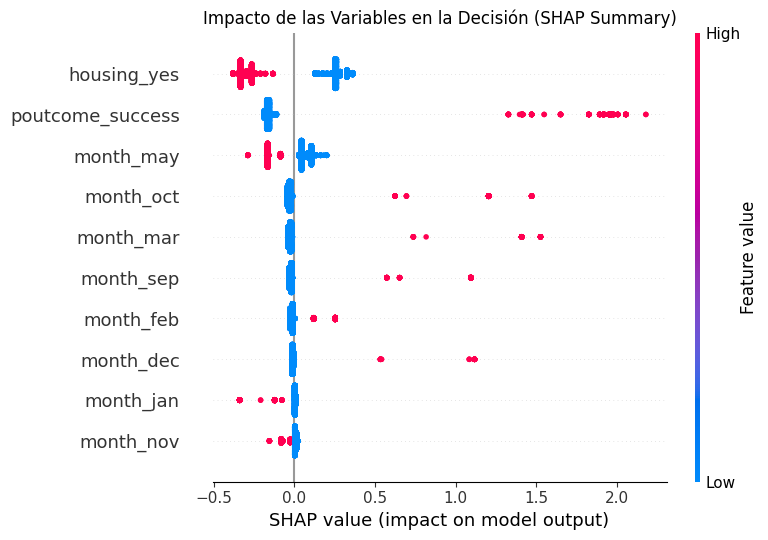

In [30]:
# =====================================================================
# PASO 5: INTERPRETACIÓN CON SHAP
# =====================================================================
print("\n5. Generando visualización de interpretación (SHAP)...")
# Configuramos el "explicador" matemático de SHAP
explainer = shap.TreeExplainer(modelo_final_optimizado)

# Calculamos los valores SHAP para el conjunto de prueba
# (Usamos test para ver cómo toma decisiones en datos que no ha visto)
shap_values = explainer.shap_values(X_test)

# Mostramos el gráfico resumen
plt.title("Impacto de las Variables en la Decisión (SHAP Summary)")
shap.summary_plot(shap_values, X_test)